# Monte Carlo Simulation & Options Pricing

Princg of European options using Monte Carlo simulation based on Geometric Brownian Motion 
Comparison of the results with the BS model 
Real historical data is downloaded via yfinance 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yfinance as yf
from scipy.stats import norm
import warnings

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 13})
print("libraries imported successfully")

libraries imported successfully


## 1. Historical Data & GBM Parameter Calibration

We download 2 years of daily close prices and estimate:
- **μ** (drift): annualised expected log-return
- **σ** (volatility): annualised standard deviation of log-returns

In [3]:
TICKER = "^FCHI" # CAC 40 index
stock = yf.download(TICKER, start="2022-01-01", progress=False, auto_adjust=True)
close = stock["Close"].squeeze().dropna()

log_returns = np.log(close / close.shift(1)).dropna()

mu_daily    = float(log_returns.mean())
sigma_daily = float(log_returns.std(ddof=1))
mu_annual   = mu_daily * 252
sigma_annual = sigma_daily * np.sqrt(252)
S0 = float(close.iloc[-1])

print(f"Ticker      : {TICKER}")
print(f"Last price  : S₀ = €{S0:.2f}")
print(f"Drift  μ    : {mu_daily:.6f} / day  →  {mu_annual:.2%} / year")
print(f"Volatility σ: {sigma_daily:.6f} / day  →  {sigma_annual:.2%} / year")
print(f"Observations: {len(log_returns)}")

Ticker      : ^FCHI
Last price  : S₀ = €8151.50
Drift  μ    : 0.000108 / day  →  2.71% / year
Volatility σ: 0.010454 / day  →  16.60% / year
Observations: 1131


## 2. Simulating GBM Price Paths

The discrete GBM update rule is:

$$S_{t+dt} = S_t \cdot \exp\!\left[(\mu - \tfrac{1}{2}\sigma^2)\,dt + \sigma\sqrt{dt}\,Z\right], \quad Z \sim \mathcal{N}(0,1)$$

We simulate **1 000 paths** over a 1-year horizon (252 trading days).

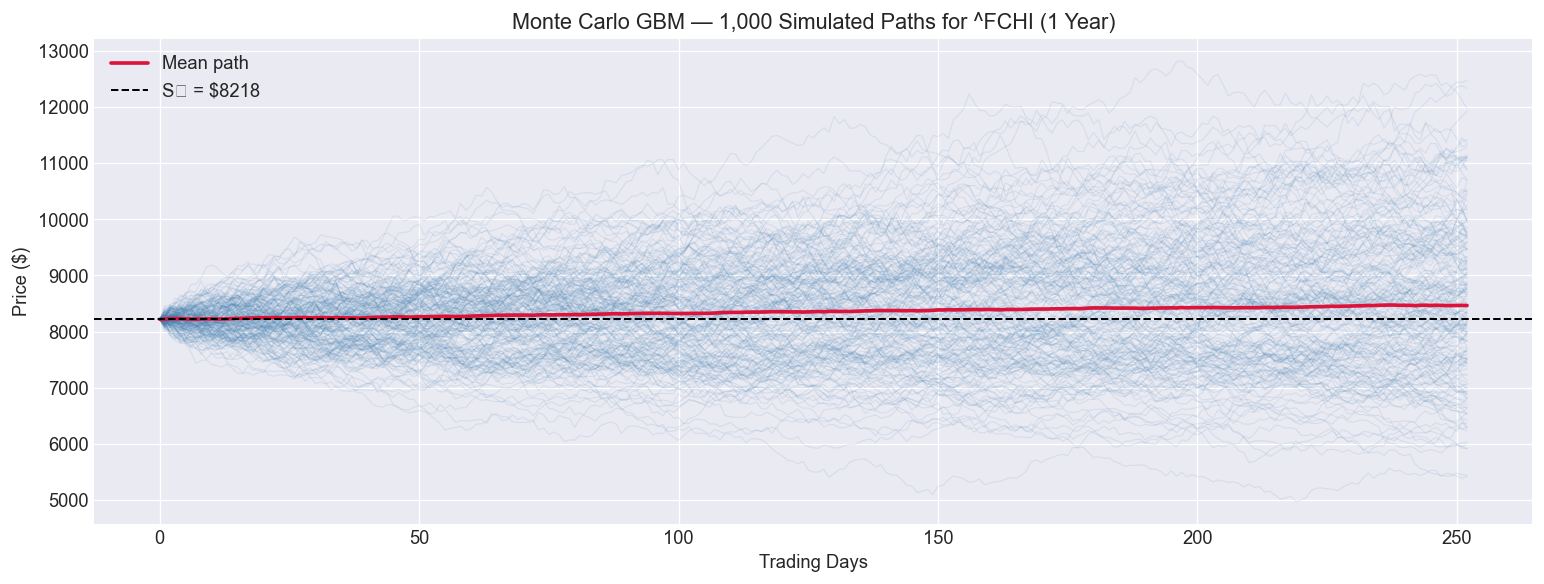

In [4]:
np.random.seed(42)
Nb_SIM  = 1_000
T_DAYS = 252

Z = np.random.standard_normal((T_DAYS, Nb_SIM))
increments = np.exp(
    (mu_daily - 0.5 * sigma_daily**2) + sigma_daily * Z
)
paths = S0 * np.cumprod(increments, axis=0)
paths = np.vstack([np.full(Nb_SIM, S0), paths])   # prepend S₀ row

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(paths[:, :200], alpha=0.12, linewidth=0.7, color="steelblue")
ax.plot(paths.mean(axis=1), color="crimson", linewidth=2.2, label="Mean path")
ax.axhline(S0, color="black", linestyle="--", linewidth=1.2, label=f"S₀ = ${S0:.0f}")
ax.set_title(f"Monte Carlo GBM — {Nb_SIM:,} Simulated Paths for {TICKER} (1 Year)")
ax.set_xlabel("Trading Days")
ax.set_ylabel("Price ($)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Terminal Price Distribution & Risk Metrics

The terminal price distribution is approximately **log-normal**.
We extract:
- **VaR 95% / 99%** (downside threshold at confidence level)
- **CVaR 95%** (expected loss beyond VaR, also called Expected Shortfall)

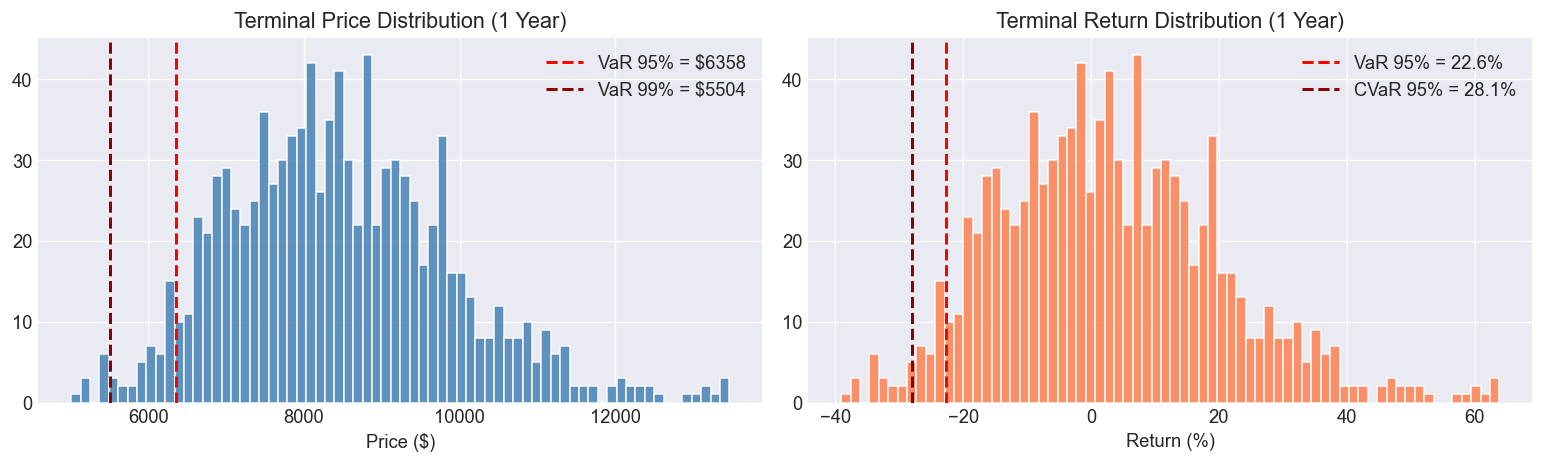

VaR  95% : 22.6%  →  floor price $6357.51
VaR  99% : 33.0%  →  floor price $5504.30
CVaR 95% : 28.1%


In [5]:
terminal_prices  = paths[-1, :]
terminal_returns = terminal_prices / S0 - 1

var_95_ret  = -np.percentile(terminal_returns, 5)
var_99_ret  = -np.percentile(terminal_returns, 1)
cvar_95_ret = -terminal_returns[terminal_returns < np.percentile(terminal_returns, 5)].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(terminal_prices, bins=70, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(np.percentile(terminal_prices, 5), color="red",
                linestyle="--", linewidth=1.8, label=f"VaR 95% = ${np.percentile(terminal_prices,5):.0f}")
axes[0].axvline(np.percentile(terminal_prices, 1), color="darkred",
                linestyle="--", linewidth=1.8, label=f"VaR 99% = ${np.percentile(terminal_prices,1):.0f}")
axes[0].set_title("Terminal Price Distribution (1 Year)")
axes[0].set_xlabel("Price ($)")
axes[0].legend()

axes[1].hist(terminal_returns * 100, bins=70, color="coral", edgecolor="white", alpha=0.85)
axes[1].axvline(-var_95_ret * 100, color="red", linestyle="--", linewidth=1.8,
                label=f"VaR 95% = {var_95_ret:.1%}")
axes[1].axvline(-cvar_95_ret * 100, color="darkred", linestyle="--", linewidth=1.8,
                label=f"CVaR 95% = {cvar_95_ret:.1%}")
axes[1].set_title("Terminal Return Distribution (1 Year)")
axes[1].set_xlabel("Return (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"VaR  95% : {var_95_ret:.1%}  →  floor price ${S0 * (1 - var_95_ret):.2f}")
print(f"VaR  99% : {var_99_ret:.1%}  →  floor price ${S0 * (1 - var_99_ret):.2f}")
print(f"CVaR 95% : {cvar_95_ret:.1%}")

## 4. Black-Scholes Pricing & Greeks

The closed-form Black-Scholes price for a European call is:

$$C = S_0 \,N(d_1) - K e^{-rT}\,N(d_2)$$

$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

We compare with Monte Carlo pricing.

In [6]:
def black_scholes(S, K, T, r, sigma, kind="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if kind == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        delta = norm.cdf(d1)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
        delta = norm.cdf(d1) - 1
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega  = S * norm.pdf(d1) * np.sqrt(T) / 100
    theta = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
             - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    return {"price": price, "delta": delta, "gamma": gamma,
            "vega": vega, "theta": theta}

r_f = 0.045   # risk-free rate (approx 3-month US T-bill)
T   = 1.0     # 1-year horizon
K   = S0      # at-the-money

bs_call = black_scholes(S0, K, T, r_f, sigma_annual, "call")
bs_put  = black_scholes(S0, K, T, r_f, sigma_annual, "put")

# Monte Carlo prices (risk-neutral: replace μ with r_f)
Z_rn = np.random.standard_normal((T_DAYS, 10_000))
inc_rn = np.exp((r_f / 252 - 0.5 * sigma_daily**2) + sigma_daily * Z_rn)
paths_rn = S0 * np.cumprod(inc_rn, axis=0)
terminal_rn = paths_rn[-1, :]

mc_call = float(np.exp(-r_f * T) * np.maximum(terminal_rn - K, 0).mean())
mc_put  = float(np.exp(-r_f * T) * np.maximum(K - terminal_rn, 0).mean())

print(f"{'─'*52}")
print(f"  ATM Option  S={S0:.0f}  K={K:.0f}  T=1Y  r={r_f:.1%}  σ={sigma_annual:.1%}")
print(f"{'─'*52}")
print(f"  {'':22s}   {'CALL':>8s}   {'PUT':>8s}")
print(f"  {'Black-Scholes':22s}   ${bs_call['price']:>7.2f}   ${bs_put['price']:>7.2f}")
print(f"  {'Monte Carlo (10k)':22s}   ${mc_call:>7.2f}   ${mc_put:>7.2f}")
print(f"{'─'*52}")
print("  Greeks — ATM Call")
for g, v in bs_call.items():
    print(f"    {g:8s}: {v:+.4f}")

────────────────────────────────────────────────────
  ATM Option  S=8218  K=8218  T=1Y  r=4.5%  σ=16.6%
────────────────────────────────────────────────────
                               CALL        PUT
  Black-Scholes            $ 731.79   $ 370.17
  Monte Carlo (10k)        $ 722.72   $ 377.97
────────────────────────────────────────────────────
  Greeks — ATM Call
    price   : +731.7926
    delta   : +0.6384
    gamma   : +0.0003
    vega    : +30.7936
    theta   : -1.2567


## 5. Convergence Analysis

How many simulations are needed to converge to the Black-Scholes price?

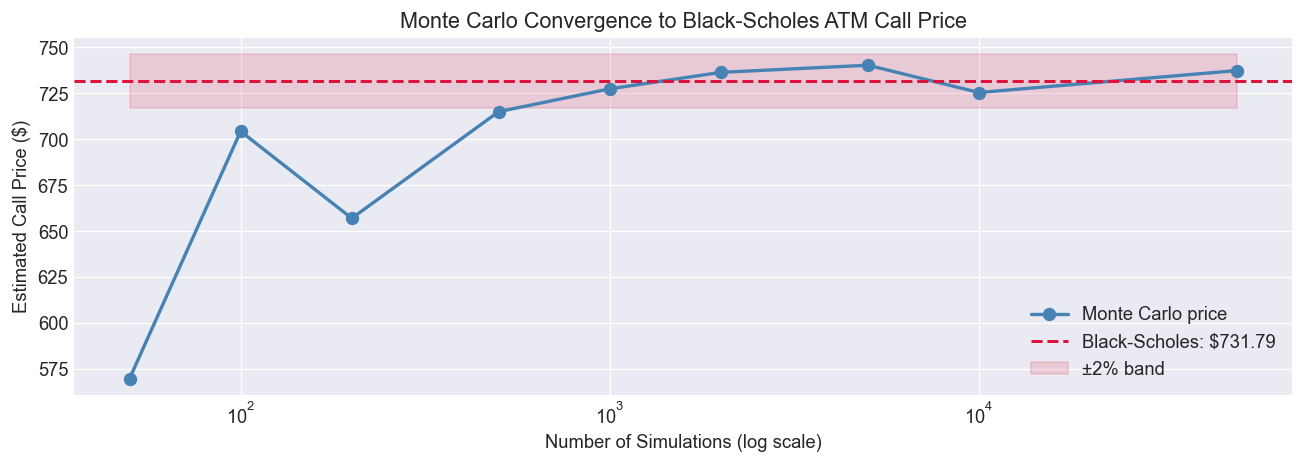

In [7]:
sim_counts = [50, 100, 200, 500, 1_000, 2_000, 5_000, 10_000, 50_000]
mc_convergence = []

for n in sim_counts:
    np.random.seed(0)
    Z_ = np.random.standard_normal((T_DAYS, n))
    inc_ = np.exp((r_f / 252 - 0.5 * sigma_daily**2) + sigma_daily * Z_)
    term_ = (S0 * np.cumprod(inc_, axis=0))[-1]
    mc_convergence.append(np.exp(-r_f * T) * np.maximum(term_ - K, 0).mean())

fig, ax = plt.subplots(figsize=(11, 4))
ax.semilogx(sim_counts, mc_convergence, "o-", color="steelblue",
            linewidth=2, markersize=7, label="Monte Carlo price")
ax.axhline(bs_call["price"], color="crimson", linestyle="--",
           linewidth=1.8, label=f"Black-Scholes: ${bs_call['price']:.2f}")
ax.fill_between(sim_counts,
                bs_call["price"] * 0.98, bs_call["price"] * 1.02,
                alpha=0.15, color="crimson", label="±2% band")
ax.set_title("Monte Carlo Convergence to Black-Scholes ATM Call Price")
ax.set_xlabel("Number of Simulations (log scale)")
ax.set_ylabel("Estimated Call Price ($)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Strike Sensitivity: Option Price & Delta vs Strike

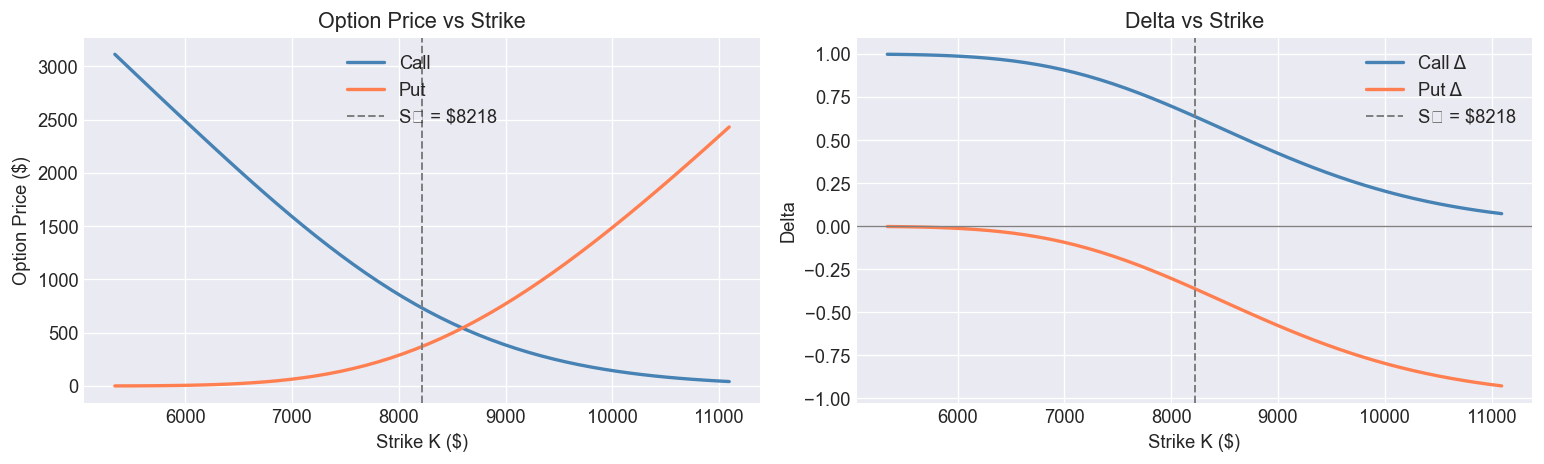

In [8]:
strikes = np.linspace(S0 * 0.65, S0 * 1.35, 50)
call_prices = [black_scholes(S0, k, T, r_f, sigma_annual, "call")["price"] for k in strikes]
put_prices  = [black_scholes(S0, k, T, r_f, sigma_annual, "put")["price"]  for k in strikes]
call_deltas = [black_scholes(S0, k, T, r_f, sigma_annual, "call")["delta"] for k in strikes]
put_deltas  = [black_scholes(S0, k, T, r_f, sigma_annual, "put")["delta"]  for k in strikes]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(strikes, call_prices, color="steelblue", linewidth=2, label="Call")
axes[0].plot(strikes, put_prices,  color="coral",     linewidth=2, label="Put")
axes[0].axvline(S0, color="gray", linestyle="--", linewidth=1.2, label=f"S₀ = ${S0:.0f}")
axes[0].set_title("Option Price vs Strike")
axes[0].set_xlabel("Strike K ($)")
axes[0].set_ylabel("Option Price ($)")
axes[0].legend()

axes[1].plot(strikes, call_deltas, color="steelblue", linewidth=2, label="Call Δ")
axes[1].plot(strikes, put_deltas,  color="coral",     linewidth=2, label="Put Δ")
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].axvline(S0, color="gray", linestyle="--", linewidth=1.2, label=f"S₀ = ${S0:.0f}")
axes[1].set_title("Delta vs Strike")
axes[1].set_xlabel("Strike K ($)")
axes[1].set_ylabel("Delta")
axes[1].legend()

plt.tight_layout()
plt.show()